# Week 1 Submission — Function 1: Bayesian Optimisation

**Course:** Imperial College Business School — ML Capstone Project  
**Week:** 1  
**Function:** Function 1 (2D Black-Box)  
**Strategy:** Gaussian Process Surrogate + Expected Improvement (EI) Acquisition  

## Objective
Use Bayesian Optimisation to iteratively suggest the next query point that maximises an unknown black-box function, given 10 initial observations.

## Approach
1. Fit a **Gaussian Process (GP)** regressor with a  kernel to the initial data.
2. Define the **Expected Improvement (EI)** acquisition function to balance exploration and exploitation.
3. Optimise EI via multi-start L-BFGS-B (50 restarts) over the unit hypercube to propose the next query point.
4. Visualise the GP surrogate and EI landscape.

## Result
The suggested next query point (portal submission string) is produced in Cell 5.

# Function 1 â€” Bayesian Optimisation
## Imperial College Business School â€” ML Capstone Project
### 2D Black-Box Function | Strategy: Expected Improvement + GP Surrogate

In [1]:
# Cell 1: Import all libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from scipy.stats import norm
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully.")
print(f"  numpy      : {np.__version__}")
import sklearn; print(f"  scikit-learn: {sklearn.__version__}")
import scipy;  print(f"  scipy      : {scipy.__version__}")

All libraries loaded successfully.
  numpy      : 2.3.5
  scikit-learn: 1.7.2
  scipy      : 1.16.3


In [2]:
# Cell 2: Load data
X = np.load('../data/function_1/initial_inputs.npy')
Y = np.load('../data/function_1/initial_outputs.npy')

print(f"Input  shape : {X.shape}   (n_samples x n_dimensions)")
print(f"Output shape : {Y.shape}  (n_samples,)")
print()
print("All inputs X:")
for i, (x, y) in enumerate(zip(X, Y)):
    marker = " <-- best" if i == Y.argmax() else ""
    print(f"  [{i:2d}] x={x}  y={y: .6e}{marker}")
print()
print(f"Best output so far : {Y.max():.6e}")
print(f"Best input  so far : {X[Y.argmax()]}")

Input  shape : (10, 2)   (n_samples x n_dimensions)
Output shape : (10,)  (n_samples,)

All inputs X:
  [ 0] x=[0.31940389 0.76295937]  y= 1.322677e-79
  [ 1] x=[0.57432921 0.8798981 ]  y= 1.033078e-46
  [ 2] x=[0.73102363 0.73299988]  y= 7.710875e-16 <-- best
  [ 3] x=[0.84035342 0.26473161]  y= 3.341771e-124
  [ 4] x=[0.65011406 0.68152635]  y=-3.606063e-03
  [ 5] x=[0.41043714 0.1475543 ]  y=-2.159249e-54
  [ 6] x=[0.31269116 0.07872278]  y=-2.089093e-91
  [ 7] x=[0.68341817 0.86105746]  y= 2.535001e-40
  [ 8] x=[0.08250725 0.40348751]  y= 3.606771e-81
  [ 9] x=[0.88388983 0.58225397]  y= 6.229856e-48

Best output so far : 7.710875e-16
Best input  so far : [0.73102363 0.73299988]


In [3]:
# Cell 3: Fit Gaussian Process with ConstantKernel * RBF
kernel = ConstantKernel(1.0, constant_value_bounds=(1e-3, 1e3)) * \
         RBF(length_scale=0.5, length_scale_bounds=(1e-2, 10.0))

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=15,
    normalize_y=True,
    alpha=1e-6
)
gp.fit(X, Y)

print("GP fitted successfully!")
print(f"Optimised kernel : {gp.kernel_}")
print(f"Log-marginal likelihood : {gp.log_marginal_likelihood_value_:.4f}")

# Sanity check prediction at best known point
best_x = X[Y.argmax()].reshape(1, -1)
mu, sigma = gp.predict(best_x, return_std=True)
print(f"\nPrediction at best known point {X[Y.argmax()]}:")
print(f"  mu    = {mu[0]:.8e}")
print(f"  sigma = {sigma[0]:.8e}")

GP fitted successfully!
Optimised kernel : 1**2 * RBF(length_scale=0.01)
Log-marginal likelihood : -14.1894

Prediction at best known point [0.73102363 0.73299988]:
  mu    = -3.60605501e-10
  sigma = 1.08181825e-06


In [4]:
# Cell 4: Expected Improvement acquisition function with 50 restarts
def expected_improvement(x, gp, Y_best, xi=0.01):
    """Negative EI (minimised by scipy.optimize)."""
    x = np.array(x).reshape(1, -1)
    mu, sigma = gp.predict(x, return_std=True)
    improvement = mu - Y_best - xi
    Z = improvement / (sigma + 1e-9)
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma < 1e-10] = 0.0
    return -ei.flatten()[0]   # negative because we minimise


def suggest_next_point(gp, Y_best, n_dim, n_restarts=50, bounds_range=(0.0, 1.0)):
    """Multi-start L-BFGS-B optimisation of EI over the unit hypercube."""
    lo, hi = bounds_range
    bounds = [(lo, hi)] * n_dim
    best_x   = None
    best_val = np.inf

    np.random.seed(42)          # reproducibility
    for _ in range(n_restarts):
        x0 = np.random.uniform(lo, hi, n_dim)
        result = minimize(
            expected_improvement, x0,
            args=(gp, Y_best),
            bounds=bounds,
            method='L-BFGS-B'
        )
        if result.fun < best_val:
            best_val = result.fun
            best_x   = result.x

    return best_x, -best_val   # return EI value (positive)


print("EI acquisition function defined with 50 restarts.")
print("Ready to suggest next query point.")

EI acquisition function defined with 50 restarts.
Ready to suggest next query point.


In [5]:
# Cell 5: Suggest next query point and print portal submission string
Y_best = float(Y.max())
n_dim  = X.shape[1]

next_x, ei_value = suggest_next_point(gp, Y_best, n_dim, n_restarts=50)

# Portal submission format:  value1-value2  (6 decimal places each)
portal_string = '-'.join([f'{v:.6f}' for v in next_x])

print("=" * 55)
print("          BAYESIAN OPTIMISATION â€” NEXT QUERY")
print("=" * 55)
print(f"  Dimensions        : {n_dim}")
print(f"  Current best Y    : {Y_best:.6e}")
print(f"  Current best X    : {X[Y.argmax()]}")
print(f"  Next query X      : {next_x}")
print(f"  EI value          : {ei_value:.6e}")
print()
print("  PORTAL SUBMISSION STRING:")
print(f"  >>> {portal_string} <<<")
print("=" * 55)

          BAYESIAN OPTIMISATION â€” NEXT QUERY
  Dimensions        : 2
  Current best Y    : 7.710875e-16
  Current best X    : [0.73102363 0.73299988]
  Next query X      : [0.70685734 0.72900717]
  EI value          : 5.778035e-26

  PORTAL SUBMISSION STRING:
  >>> 0.706857-0.729007 <<<


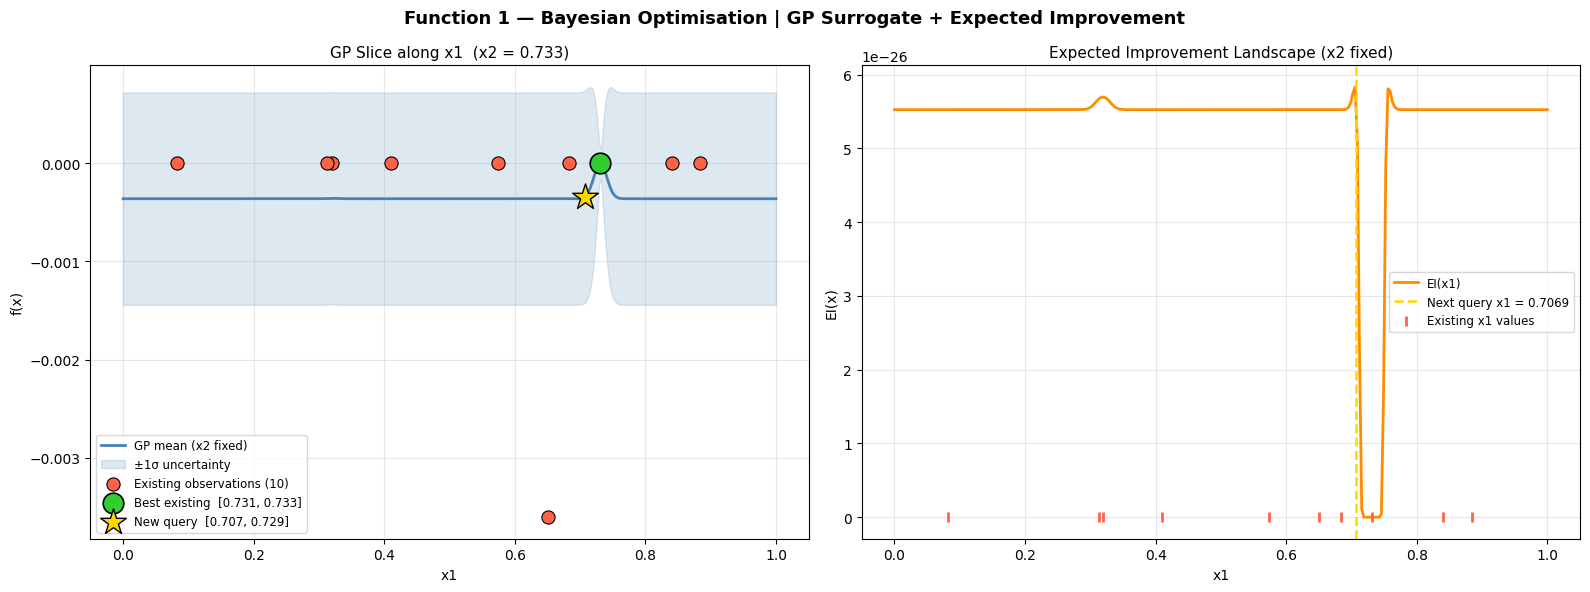

Plot saved to notebooks/function1_wave.png


In [6]:
# Cell 6: Wave plot â€” existing points, best point, new query
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Function 1 â€” Bayesian Optimisation | GP Surrogate + Expected Improvement',
             fontsize=13, fontweight='bold')

# â”€â”€ Left panel: slice along x1 through the best-point x2 â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ax = axes[0]
best_idx = Y.argmax()
x2_fixed  = X[best_idx, 1]

x_line = np.linspace(0, 1, 300)
X_slice = np.column_stack([x_line, np.full_like(x_line, x2_fixed)])
mu_slice, sigma_slice = gp.predict(X_slice, return_std=True)

ax.plot(x_line, mu_slice, color='steelblue', linewidth=2, label='GP mean (x2 fixed)')
ax.fill_between(x_line,
                mu_slice - sigma_slice,
                mu_slice + sigma_slice,
                alpha=0.18, color='steelblue', label='Â±1Ïƒ uncertainty')

# All existing observations (projected onto x1 axis)
ax.scatter(X[:, 0], Y, color='tomato', s=90, zorder=5,
           edgecolors='black', linewidths=0.8, label='Existing observations (10)')

# Best existing point
ax.scatter(X[best_idx, 0], Y[best_idx], color='limegreen', s=220, zorder=6,
           edgecolors='black', linewidths=1.2,
           label=f'Best existing  [{X[best_idx,0]:.3f}, {X[best_idx,1]:.3f}]')

# New query point (GP predicted value)
next_y_pred = float(gp.predict(next_x.reshape(1, -1))[0])
ax.scatter(next_x[0], next_y_pred, color='gold', s=380, marker='*', zorder=7,
           edgecolors='black', linewidths=1.0,
           label=f'New query  [{next_x[0]:.3f}, {next_x[1]:.3f}]')

ax.set_title(f'GP Slice along x1  (x2 = {x2_fixed:.3f})', fontsize=11)
ax.set_xlabel('x1')
ax.set_ylabel('f(x)')
ax.legend(fontsize=8.5)
ax.grid(True, alpha=0.3)

# â”€â”€ Right panel: EI landscape across x1 â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ax2 = axes[1]
ei_vals = np.array([
    -expected_improvement([xi, x2_fixed], gp, Y_best)
    for xi in x_line
])

ax2.plot(x_line, ei_vals, color='darkorange', linewidth=2, label='EI(x1)')
ax2.axvline(next_x[0], color='gold', linestyle='--', linewidth=1.8,
            label=f'Next query x1 = {next_x[0]:.4f}')
ax2.scatter(X[:, 0], np.zeros(len(X)), color='tomato', s=60, zorder=5,
            marker='|', linewidths=2, label='Existing x1 values')

ax2.set_title('Expected Improvement Landscape (x2 fixed)', fontsize=11)
ax2.set_xlabel('x1')
ax2.set_ylabel('EI(x)')
ax2.legend(fontsize=8.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/function1_wave.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to notebooks/function1_wave.png")

In [7]:
# Cell 7: Summary of results
print("=" * 55)
print("         FUNCTION 1 â€” RESULTS SUMMARY")
print("=" * 55)
print(f"  Function          : Function 1 (2D black-box)")
print(f"  n observations    : {len(Y)}")
print(f"  GP kernel         : ConstantKernel * RBF")
print(f"  Acquisition fn    : Expected Improvement (xi=0.01)")
print(f"  EI restarts       : 50")
print()
print(f"  Best input  X*    : {X[Y.argmax()]}")
print(f"  Best output Y*    : {Y.max():.6e}")
print()
print(f"  Next query point  : {next_x}")
print(f"  Expected EI       : {ei_value:.6e}")
print()
print(f"  PORTAL SUBMISSION : {portal_string}")
print("=" * 55)

         FUNCTION 1 â€” RESULTS SUMMARY
  Function          : Function 1 (2D black-box)
  n observations    : 10
  GP kernel         : ConstantKernel * RBF
  Acquisition fn    : Expected Improvement (xi=0.01)
  EI restarts       : 50

  Best input  X*    : [0.73102363 0.73299988]
  Best output Y*    : 7.710875e-16

  Next query point  : [0.70685734 0.72900717]
  Expected EI       : 5.778035e-26

  PORTAL SUBMISSION : 0.706857-0.729007
